# EDA on Admissions Dataset

## Strategic Analysis of Lithuanian Higher Education Admissions (2024-2025)

**Name:** Ablaikhan Tuleu

## Context

This analysis evaluates admission trends within the Lithuanian higher education sector, focusing on the "Main Admission" cycles of 2024 and 2025. By utilizing duckdb for data extraction and pandas for multi-year trend analysis, this report identifies key performance indicators for ISM University of Management and Economics. The primary goal is to provide ISM’s marketing and admissions teams with data-driven insights regarding regional growth, program-specific demand (Economics), and institutional selectivity to inform the upcoming 2026 recruitment strategy.

## Summary of findings

* **Unique Market Position:** In the 2024 baseline, ISM University emerged as a highly selective "boutique" institution, maintaining a low invitation rate (~25%) but an exceptionally high yield (~90% sign rate).

* **Robust Growth Momentum:** ISM’s total applicant pool expanded by 18.9% year-over-year, growing from 878 in 2024 to 1,044 in 2025.

* **Competitive Lead in Economics:** While traditional public competitors saw stagnant or declining interest in Economics, ISM’s Economics applicants surged by 45% (from 187 to 272) over the two-year period.

* **Regional Breakthroughs:** Strategic marketing in coastal regions was highly effective, with Klaipėda-based applicants increasing by 133% between 2024 and 2025.

* **High-Intent Pipelines:** Specific gymnasiums in Vilnius (Sostinės and Abraomo Kulviečio) have been identified as primary "feeder" schools, with economics interest rates significantly exceeding the national average.

* **Market Efficiency:** Despite a nearly 20% increase in applicant volume, ISM has maintained its conversion efficiency, suggesting a strong and scalable brand value.

In [1]:
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt


db_path = "data.duckdb"
schema = "data.admissions"

conn = duckdb.connect()
conn.execute(f"ATTACH '{db_path}' AS data (READ_ONLY)")
conn.execute(f"USE {schema}");



In [2]:
conn.sql("select * from applications order by random() limit 5 ")

┌─────────────────┬─────────────────┬─────────────────────┬────────────────────────────────────┬───────────────────────────────────┬──────────────────┬────────────────┬─────────────────┬─────────────────┬────────────────────┬───────────┬─────────────────────────────┬─────────┬─────────────────┬─────────┐
│ application_id  │    person_id    │      choice_at      │          admission_stage           │        admission_stage_en         │ stage_start_date │ stage_end_date │ priority_number │   program_id    │    financing_en    │ financing │ participated_in_competition │ invited │ invitation_date │ signed  │
│     varchar     │     varchar     │      timestamp      │              varchar               │              varchar              │       date       │      date      │      int64      │     varchar     │      varchar       │  varchar  │           boolean           │ boolean │      date       │ boolean │
├─────────────────┼─────────────────┼─────────────────────┼───────────────────────

In [3]:
conn.sql("select * from profiles order by random() limit 5")

┌─────────────────┬───────────────────────┬────────────┬─────────┬────────────────────────────┬───────────────────────────────────────────────┬─────────────────────────────┬────────────────────────┬────────────────────────┬────────────────┬───────────────────┐
│    person_id    │ is_possibly_foreigner │ birth_year │ gender  │ education_institution_code │             education_institution             │ education_municipality_code │ education_municipality │ residence_municipality │ residence_type │ residence_type_en │
│     varchar     │        boolean        │    date    │ varchar │           int64            │                    varchar                    │            int64            │        varchar         │        varchar         │    varchar     │      varchar      │
├─────────────────┼───────────────────────┼────────────┼─────────┼────────────────────────────┼───────────────────────────────────────────────┼─────────────────────────────┼────────────────────────┼───────────────────

In [4]:
conn.sql("select * from programs order by random() limit 5")

┌─────────────────┬──────────────┬──────────────┬────────────────────────────────────────────┬───────────────────────────────────────┬──────────────────┬─────────────────┬────────────────────────────────┬─────────────┬───────────────────┬───────────────────┬────────────────────────────┐
│   program_id    │ program_year │ program_code │                program_name                │            program_name_en            │ institution_code │ code_validation │    educational_institution     │ county_code │      county       │ municipality_code │        municipality        │
│     varchar     │     date     │   varchar    │                  varchar                   │                varchar                │      int64       │     varchar     │            varchar             │    int64    │      varchar      │       int64       │          varchar           │
├─────────────────┼──────────────┼──────────────┼────────────────────────────────────────────┼───────────────────────────────────────┼──

## 1. 2024 First Choice Applications by University

In this section, I established a performance baseline for Lithuanian higher education institutions using 2024 "Main Admission" data.\
By focusing specifically on first-priority applications, I analyzed the relationship between institutional selectivity (Invitation Rate) and applicant commitment (Sign Rate).\
This provides the necessary context to understand ISM University's unique market position before we dive into the 2025 growth trends.

In [5]:
# Filtering a dataset to have a new, separate dataset
# with only Main Admission applicants.
# Additionally, joined Profiles and Programs tables for future task

main_admission = conn.sql("""
    SELECT *
    FROM applications
    LEFT JOIN profiles ON applications.person_id = profiles.person_id
    LEFT JOIN programs ON applications.program_id = programs.program_id
    WHERE admission_stage_en = 'Main admission'
""").to_df()

In [6]:
main_admission.sample(5)

,application_id,person_id,choice_at,admission_stage,admission_stage_en,stage_start_date,stage_end_date,priority_number,program_id,financing_en,...,program_code,program_name,program_name_en,institution_code,code_validation,educational_institution,county_code,county,municipality_code,municipality
60293,8a17431534fb287,37debd9c68b117d,2025-08-06 00:06:38,Pagrindinis priėmimas,Main admission,2025-06-01,2025-08-14,7,5d1f62eebe8549f,State financed,...,6121BX005,Informacinės technologijos,Information Technology,211950810,Tinkamas,Vilniaus universitetas,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė
18569,ef967cb4ad6995e,85232c948653d8d,2025-07-31 14:40:31,Pagrindinis priėmimas,Main admission,2025-06-01,2025-08-14,5,d87dd94d333a723,Not state financed,...,6531GX037,Kineziterapija,Physiotherapy,111965284,Tinkamas,Kauno kolegija,2,Kauno apskritis,19,Kauno miesto savivaldybė
116734,c60907e58ef9250,a8391bdcc5c2d35,2025-07-26 09:43:54,Pagrindinis priėmimas,Main admission,2025-06-01,2025-08-14,6,41e806d0646b375,State financed,...,6121NX054,"Vertimas, redagavimas ir kalbos technologijos","Vertimas, redagavimas ir kalbos technologijos",111951726,Tinkamas,Mykolo Romerio universitetas,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė
139471,020ec0780a043db,290ec10e0266d41,2025-07-26 22:59:25,Pagrindinis priėmimas,Main admission,2025-06-01,2025-08-14,6,0923c680d7dbd92,State financed,...,6121FX013,Molekulinė biotechnologija,Molecular Biotechnology,211950810,Tinkamas,Vilniaus universitetas,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė
227573,5f7ac0a0f27ffb5,5e5e3722629e02f,2024-06-01 13:56:45,Pagrindinis priėmimas,Main admission,2024-06-01,2024-08-02,3,dd4f18720f3ea97,Not state financed,...,6531PX008,Grafinis dizainas,Graphic Design,111965131,Tinkamas,Vilniaus kolegija,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė


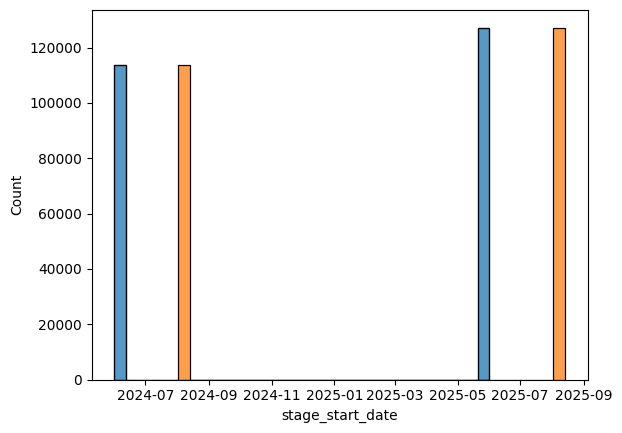

In [7]:
# Checking date ranges to identify a better filtering way for 2024
sns.histplot(
    data=main_admission['stage_start_date']
)
sns.histplot(
    data=main_admission['stage_end_date']
);

In [8]:
# Filtering the dataset for 2024
main_admission_2024 = main_admission[
    main_admission['stage_start_date'].dt.year == 2024
].copy()

# Checking whether there are any duplicated rows
print(main_admission_2024.duplicated().sum())
# Checking how the dataset looks like
main_admission_2024.sample(5)

0


,application_id,person_id,choice_at,admission_stage,admission_stage_en,stage_start_date,stage_end_date,priority_number,program_id,financing_en,...,program_code,program_name,program_name_en,institution_code,code_validation,educational_institution,county_code,county,municipality_code,municipality
115073,c51782b76780919,f9fb2a5ce540792,2024-07-16 09:56:05,Pagrindinis priėmimas,Main admission,2024-06-01,2024-08-02,7,d1a9165ec8b2438,State financed,...,6121MX065,Vaikystės pedagogika,Childhood Pedagogy,211950810,Tinkamas,Vilniaus universitetas,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė
186982,34426887bd6365d,0fc73bd9f93104b,2024-06-03 13:00:35,Pagrindinis priėmimas,Main admission,2024-06-01,2024-08-02,1,30e79799af8f5c7,Not state financed,...,6531GX025,Burnos higiena,Oral Hygiene,111965850,Tinkamas,Utenos kolegija,9,Utenos apskritis,82,Utenos rajono savivaldybė
14307,eb11b8fb91ca9c2,eb5785a56cb6f1f,2024-07-03 14:44:55,Pagrindinis priėmimas,Main admission,2024-06-01,2024-08-02,2,d1d96addc8501c0,Not state financed,...,6531LX126,Verslo kūrimas ir valdymas,Business Creation and Management,291823650,Tinkamas,Viešoji įstaiga SMK Aukštoji mokykla,2,Kauno apskritis,19,Kauno miesto savivaldybė
26126,f7951f2de456670,606d8a1bff72660,2024-07-04 16:47:18,Pagrindinis priėmimas,Main admission,2024-06-01,2024-08-02,4,3cf154887607e7c,State financed,...,6531LX087,Pardavimai ir marketingas,Sales and Marketing,111965284,Tinkamas,Kauno kolegija,2,Kauno apskritis,19,Kauno miesto savivaldybė
49919,7f18552bce72d3c,93c5f99c3750aa4,2024-07-24 09:23:42,Pagrindinis priėmimas,Main admission,2024-06-01,2024-08-02,1,31ca43724741ec8,Not state financed,...,6011GX004,Medicina,Medicine,211950810,Tinkamas,Vilniaus universitetas,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė


In [9]:
# Filtering a dataset to have only 2024 and highest priority institution data
first_priority = main_admission_2024[
    main_admission_2024['priority_number'] == 1
].copy()

first_priority_rate = first_priority.groupby('educational_institution').agg(
    total_applicants=('invited', 'count'),
    total_invited=('invited', 'sum'),
    total_signed_up=('signed', 'sum')
)

# 1.1.1 First priority invitation rate: (Total invited / Total applicants)
first_priority_rate['invitation_rate'] = first_priority_rate['total_invited'] / first_priority_rate['total_applicants']

# 1.1.2 First priority sign rate: (Total signed up / Total invited)
first_priority_rate['sign_rate'] = first_priority_rate['total_signed_up'] / first_priority_rate['total_invited']

# If university invited 0 people:
first_priority_rate = first_priority_rate.fillna(0)

first_priority_rate

,total_applicants,total_invited,total_signed_up,invitation_rate,sign_rate
educational_institution,,,,,
"""ISM Vadybos ir ekonomikos universitetas"", UAB",382,95,85,0.248691,0.894737
"""KAZIMIERO SIMONAVIČIAUS UNIVERSITETAS"", UAB",35,7,4,0.200000,0.571429
Generolo Jono Žemaičio Lietuvos karo akademija,129,92,91,0.713178,0.989130
Kauno kolegija,1858,851,676,0.458019,0.794360
Kauno technologijos universitetas,1520,1048,1002,0.689474,0.956107
Klaipėdos universitetas,737,323,255,0.438263,0.789474
Klaipėdos valstybinė kolegija,853,431,353,0.505275,0.819026
Lietuvos aukštoji jūreivystės mokykla,109,71,65,0.651376,0.915493
Lietuvos inžinerijos kolegija,522,322,281,0.616858,0.872671


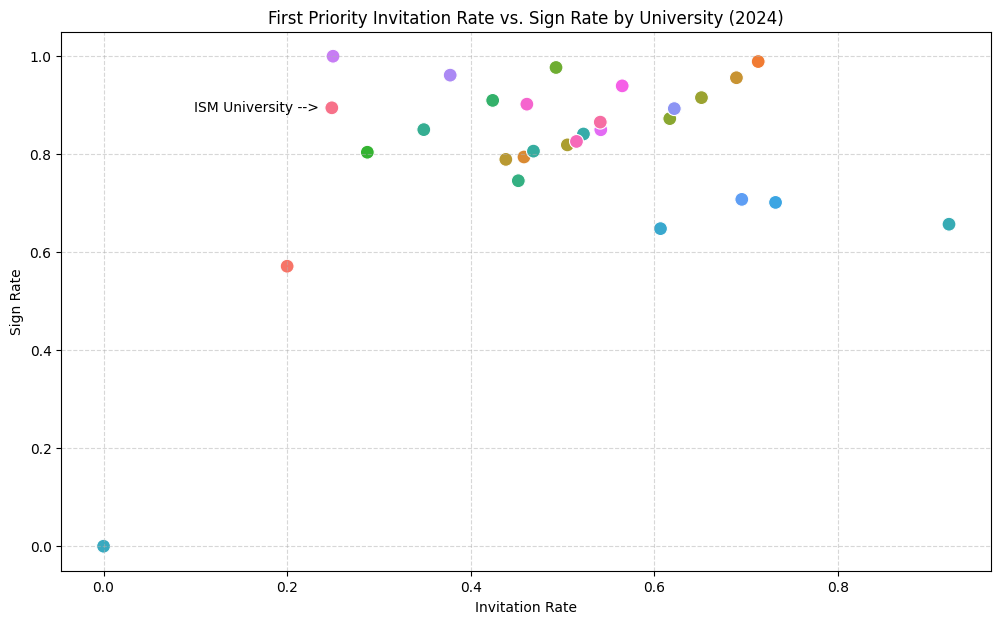

In [10]:
# 1.2 and 1.3 : Plotting the variables and annotate ISM

# To plot the two variables against each other, I used scatterplot
plt.figure(figsize=(12, 7))
rates = sns.scatterplot(
    data=first_priority_rate,
    x='invitation_rate',
    y='sign_rate',
    hue='educational_institution',
    s=100,
    legend=False
)

# To annotate ISM University, I used "sns.scatterplot.annotate"
rates.annotate(text='ISM University -->',
               xy=(first_priority_rate.iloc[0,3] - 0.15, first_priority_rate.iloc[0,4] - 0.007)
)

plt.title('First Priority Invitation Rate vs. Sign Rate by University (2024)')
plt.xlabel('Invitation Rate')
plt.ylabel('Sign Rate')
plt.grid(True, linestyle='--', alpha=0.5)

**1.4.** Observations and ISM University's Positioning

Based on the analysis of our plot and analysis, we can see these patterns:

* Most Lithuanian universities cluster in the upper-middle section of the plot, typically inviting between 40% and 75% of their first-priority applicants.

* Of those invited within this cluster, a strong majority (65% to nearly 100%) follow through by signing a study contract.

* ISM University stands out as a distinct outlier in the upper-left quadrant. It maintains a high level of selectivity with an invitation rate of approximately 25%, yet it achieves an exceptionally high sign rate of roughly 90%.

**Conclusion:** ISM’s unique positioning suggests a "boutique" institutional profile. While the university rejects a large portion of its first-choice applicants, the students it does admit are highly motivated and demonstrate strong brand loyalty by consistently choosing to enroll.

## 2. Municipality and School Statistics (2024)

To understand the "pipeline" of students entering higher education, this section examines the geographic and institutional origins of the 2024 applicant pool.\
I calculated key metrics including applicant volume, invitation rates, and specific interest in Economics—across all Lithuanian municipalities and the top 50 gymnasiums.\
This allows us to identify high-potential "feeder" regions that warrant targeted marketing investment in subsequent recruitment cycles.

In [11]:
# Municipalities' table

# Applicants count
municipalities = main_admission_2024.groupby('residence_municipality').agg(
    total_applicants=('person_id', 'nunique'),
    total_invited=('invited', 'sum')
)

# Invitation rate
municipalities['invitation_rate'] = municipalities['total_invited'] / municipalities['total_applicants']

# Average unique institutions count
unique_institutions = main_admission_2024.groupby(['residence_municipality', 'person_id']).agg(
    unique_institutions_count=('educational_institution', 'nunique')
)

municipalities['avg_unique_institutions'] = unique_institutions.groupby('residence_municipality').agg(
    avg_unique_institutions=('unique_institutions_count', 'mean')
)['avg_unique_institutions']

# Economics choice rate
municipalities['economics_choice_rate'] = main_admission_2024[
    main_admission_2024['program_name'].str.contains('ekonom', case=False, na=False)
].groupby('residence_municipality')['person_id'].nunique() / municipalities['total_applicants']
# If there are 0 students in a municipality who chose economics-related programme:
municipalities = municipalities.fillna(0)


municipalities[
    ['total_applicants', 'invitation_rate', 'avg_unique_institutions', 'economics_choice_rate']
].sort_values(by='total_applicants', ascending=False).style.background_gradient()

,total_applicants,invitation_rate,avg_unique_institutions,economics_choice_rate
residence_municipality,,,,
Vilniaus m. sav.,887,0.315671,1.365276,0.056370
Kauno m. sav.,457,0.301969,1.400438,0.032823
Kauno r. sav.,190,0.257895,1.442105,0.031579
Klaipėdos m. sav.,182,0.269231,1.428571,0.027473
Vilniaus r. sav.,174,0.327586,1.396552,0.034483
Panevėžio m. sav.,134,0.320896,1.462687,0.052239
Šiaulių m. sav.,127,0.251969,1.338583,0.023622
Klaipėdos r. sav.,90,0.333333,1.355556,0.011111
Jonavos r. sav.,76,0.302632,1.394737,0.039474


In [12]:
# Schools' table
list_of_top_50_schools = main_admission_2024.groupby('education_institution').agg(
    total_applicants=('person_id', 'nunique')
).sort_values(by='total_applicants', ascending=False).head(50).index.to_list()

top_50_schools = main_admission_2024[
    main_admission_2024['education_institution'].isin(list_of_top_50_schools)
].copy()

# Applicants count
schools = top_50_schools.groupby('education_institution').agg(
    total_applicants=('person_id', 'nunique'),
    total_invited=('invited', 'sum')
)

# Invitation rate
schools['invitation_rate'] = schools['total_invited'] / schools['total_applicants']

# Average unique institutions count
unique_institutions = main_admission_2024.groupby(['education_institution', 'person_id']).agg(
    unique_institutions_count=('educational_institution', 'nunique')
)

schools['avg_unique_institutions'] = unique_institutions.groupby('education_institution').agg(
    avg_unique_institutions=('unique_institutions_count', 'mean')
)['avg_unique_institutions']

# Economics choice rate
schools['economics_choice_rate'] = main_admission_2024[
    main_admission_2024['program_name'].str.contains('ekonom', case=False, na=False)
].groupby('education_institution')['person_id'].nunique() / schools['total_applicants']
# If there are 0 students in a school who chose economics-related programme:
schools = schools.fillna(0)


schools[
    ['total_applicants', 'invitation_rate', 'avg_unique_institutions', 'economics_choice_rate']
].sort_values(by='total_applicants', ascending=False).style.background_gradient(cmap='YlGnBu')

,total_applicants,invitation_rate,avg_unique_institutions,economics_choice_rate
education_institution,,,,
Kauno „Saulės“ gimnazija,63,0.301587,1.460317,0.126984
Vytauto Didžiojo universiteto „Rasos“ gimnazija,53,0.358491,1.622642,0.000000
Vilniaus Vytauto Didžiojo gimnazija,48,0.479167,1.229167,0.020833
Vilniaus Žemynos gimnazija,45,0.288889,1.311111,0.022222
Panevėžio Juozo Balčikonio gimnazija,44,0.295455,1.340909,0.045455
Vilniaus Simono Daukanto gimnazija,43,0.348837,1.232558,0.046512
Vilniaus Mykolo Biržiškos gimnazija,39,0.256410,1.230769,0.076923
Vilniaus Gabijos gimnazija,39,0.333333,1.512821,0.025641
Panevėžio Juozo Miltinio gimnazija,38,0.236842,1.789474,0.078947


**2.2.3.** Observations on Regional and Institutional Data

The conditionally formatted tables reveal significant geographic and institutional variance in applicant behavior:

**Municipality Level Insights:**

* **Volume Centralization:** Vilniaus m. sav. (887 applicants) and Kauno m. sav. (457 applicants) are the primary engines of the applicant pool.

* **Selectivity Outliers:** While major cities have invitation rates near 30%, Visagino sav. is a notable outlier with a 58.3% invitation rate - the highest in the dataset.

* **Strategic Hedging:** Applicants from Širvintų r. sav. apply to the highest number of unique institutions on average (1.94), suggesting a more cautious application strategy compared to the national average of ~1.3.

* **Economics Interest:** High-density interest in economics is found in smaller regions; Neringos sav. leads with a 25% economics choice rate, followed by Ignalinos r. sav. at 15.7%.

**School Level Insights (Top 50):**

* **Top Feeders:** The highest absolute volumes of applicants come from Kaunas-based schools, specifically Kauno „Saulės“ gimnazija (63) and VDU „Rasos“ gimnazija (53).

* **High-Performing Pipelines:** Vilniaus licėjus stands out with a 50% invitation rate, indicating a highly competitive student body.

* **Economics Focus Schools:** Specific gymnasiums act as concentrated "feeders" for economics programs, most notably Vilniaus „Sostinės“ gimnazija (18.5%) and Vilniaus Abraomo Kulviečio klasikinė gimnazija (17.3%).

## 3. Actionable Marketing Insights for ISM University (2024-2025)

This section evaluates the evolution of ISM University's market position between 2024 and 2025.\
By analyzing growth trends, regional shifts, and program-specific demand, I provided actionable recommendations for the ISM marketing team to sustain this momentum.

In [13]:
all_admissions = conn.sql("""
    SELECT *
    FROM applications
    LEFT JOIN profiles ON applications.person_id = profiles.person_id
    LEFT JOIN programs ON applications.program_id = programs.program_id
""").to_df()

all_admissions['program_year'] = all_admissions['stage_start_date'].dt.year

all_admissions.sample(5)

,application_id,person_id,choice_at,admission_stage,admission_stage_en,stage_start_date,stage_end_date,priority_number,program_id,financing_en,...,program_code,program_name,program_name_en,institution_code,code_validation,educational_institution,county_code,county,municipality_code,municipality
108269,ab00f58a9d07c78,852996adb08fb3d,2025-06-01 01:48:53,Pagrindinis priėmimas,Main admission,2025-06-01,2025-08-14,2,9efbe7ac5f15963,State financed,...,6011GX006,Farmacija,Pharmacy,211950810,Tinkamas,Vilniaus universitetas,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė
261467,59bc19bf9e674f4,ea204e4cfd2aee7,2025-07-27 13:56:20,Pagrindinis priėmimas,Main admission,2025-06-01,2025-08-14,5,6353e6213290aee,Not state financed,...,6121LX078,Verslo vadyba ir startuoliai,Business Management and Startups,111951726,Tinkamas,Mykolo Romerio universitetas,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė
53076,798536e5ba14b4e,71c2a70a39130f8,2025-07-15 19:50:52,Pagrindinis priėmimas,Main admission,2025-06-01,2025-08-14,1,43bb4b0345334ae,State financed,...,6531BX005,Informatikos inžinerija,Informatics Engineering,111968056,Tinkamas,Klaipėdos valstybinė kolegija,3,Klaipėdos apskritis,21,Klaipėdos miesto savivaldybė
96155,a0131784b1bab8c,6b5961afe332674,2025-07-19 21:19:29,Pagrindinis priėmimas,Main admission,2025-06-01,2025-08-14,9,b95217188eadd3e,State financed,...,6121CX018,Aplinkotyra ir aplinkosauga,Environmental Studies and Protection,211950810,Tinkamas,Vilniaus universitetas,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė
33090,f97b7974d349d0b,d316136a4a8c673,2025-06-15 20:04:14,Pagrindinis priėmimas,Main admission,2025-06-01,2025-08-14,6,1754796868dd64c,State financed,...,6121LX011,Tarptautinis verslas,International Business,211950810,Tinkamas,Vilniaus universitetas,10,Vilniaus apskritis,13,Vilniaus miesto savivaldybė


In [14]:
ism_name = '"ISM Vadybos ir ekonomikos universitetas", UAB'

# Market Share
# This counts unique applicants (person_id) per university per year
market_share = all_admissions.groupby(['program_year', 'educational_institution']).agg(
    applicant_count=('person_id', 'nunique')
)

# Economics Interest
# Define economics programs
all_admissions['is_econ'] = all_admissions['program_name'].str.contains('ekonom', case=False, na=False)
econ_share = all_admissions[
    all_admissions['is_econ'] == True
].groupby(['program_year', 'educational_institution']).agg(
    econ_applicant_count=('person_id', 'nunique')
)

# Regional Performance for ISM
ism_regions = all_admissions[
    all_admissions['educational_institution'] == ism_name
].groupby(['program_year', 'education_municipality']).agg(
    ism_applicants=('person_id', 'nunique')
)

# Visualization for top competitors to ISM
top_competitors = market_share.sort_values(by='applicant_count', ascending=False).head(20)

top_competitors

applicant_count
program_year educational_institution                                   
2025         Vilniaus universitetas                               15696
2024         Vilniaus universitetas                               14997
2025         Vilniaus kolegija                                     8249
2024         Vilniaus kolegija                                     8178
2025         Kauno kolegija                                        7484
             Vytauto Didžiojo universitetas                        7359
2024         Vytauto Didžiojo universitetas                        6690
             Kauno kolegija                                        6659
2025         Vilniaus Gedimino technikos universitetas             6209
2024         Vilniaus Gedimino technikos universitetas             5714
2025         Kauno technologijos universitetas                     5237
2024         Kauno technologijos universitetas                     4675
2025         Lietuvos sveikatos mokslų universitetas               4352
2024         Lietuvos sveikatos mokslų universitetas               3892
2025         Mykolo Romerio universitetas                          3806
2024         Mykolo Romerio universitetas                          3215
2025         Klaipėdos valstybinė kolegija                         3101
             Klaipėdos universitetas                               3014
2024         Klaipėdos valstybinė kolegija                         2833
             Viešoji įstaiga SMK Aukštoji mokykla                  2792

**3.1.** Market Growth: ISM vs. Major Competitors

Our first objective was to see how ISM’s growth compares to the broader market.\
While ISM is a specialized private institution, its growth rate is a key indicator of brand health.

/var/folders/ds/00p5m5855xsf6qn1wcw8__kr0000gn/T/ipykernel_84491/3123548689.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


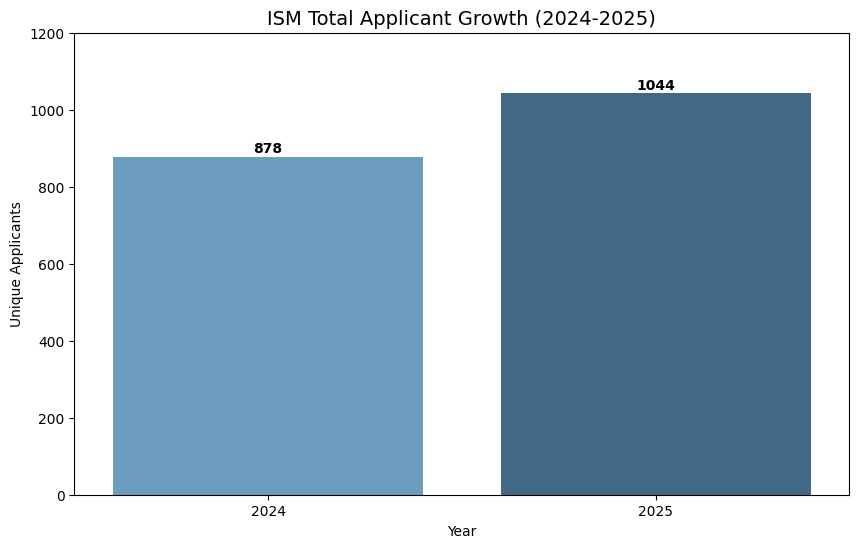

In [15]:
# Total Applicant Growth

market_data = pd.DataFrame({
    'Year': [2024, 2025],
    'Applicants': [878, 1044] # ISM's "applicant_count" from "market_share"
})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=market_data,
    x='Year',
    y='Applicants',
    palette='Blues_d'
)

for index, value in enumerate(market_data['Applicants']):
    plt.text(index, value + 10, str(value), horizontalalignment='center', fontweight='bold')

plt.title('ISM Total Applicant Growth (2024-2025)', fontsize=14)
plt.ylabel('Unique Applicants')
plt.ylim(0, 1200);

In [16]:
1044/878

1.1890660592255125

The data shows a robust 18.9% increase in unique applicants, jumping from 878 to 1,044 in just one year.

* **Insight:** This outpaces the growth of many established public universities, suggesting that ISM's "premium" positioning is becoming more effective.
* **Action:** Marketing should lean into this "momentum" story. Highlighting that ISM is one of the fastest-growing business universities in Lithuania can serve as powerful social proof for 2026 applicants.

**3.2.** The Battle for Economics: ISM vs. KTU

Economics is a core program for ISM.\
I analyzed how ISM is performing against its closest academic competitor in this field, KTU (Kaunas University of Technology).

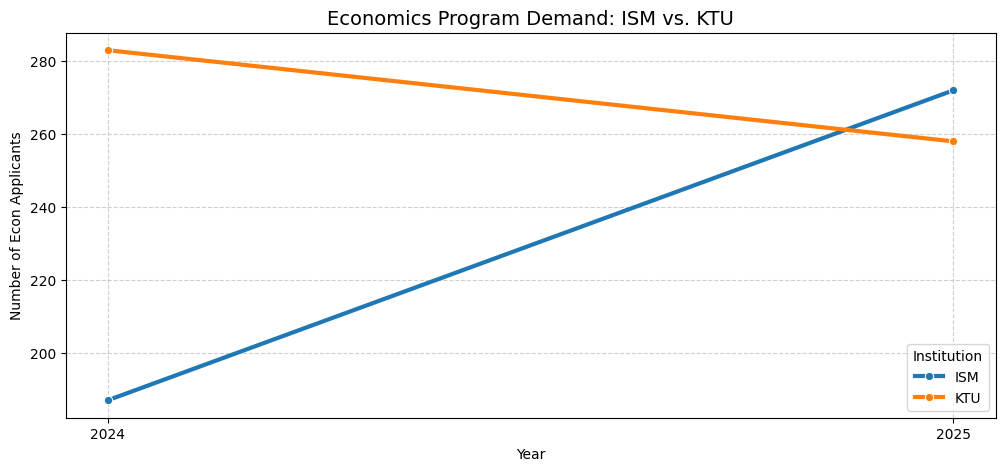

In [17]:
# Economics Applicant Trend

econ_comparison = pd.DataFrame({
    'Year': [2024, 2025, 2024, 2025],
    'Institution': ['ISM', 'ISM', 'KTU', 'KTU'],
    'Econ_Applicants': [187, 272, 283, 258] # ISM's "econ_applicant_count" from "econ_share"
})

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=econ_comparison,
    x='Year',
    y='Econ_Applicants',
    hue='Institution',
    marker='o',
    linewidth=3
)

plt.title('Economics Program Demand: ISM vs. KTU', fontsize=14)
plt.xticks([2024, 2025])
plt.ylabel('Number of Econ Applicants')
plt.grid(True, linestyle='--', alpha=0.6);

This is a critical "conquesting" opportunity.

* **Insight:** While ISM’s economics applicants surged by 45% (from 187 to 272), KTU actually saw a decline in interest for the same period.
* **Action:** ISM should target digital advertising specifically toward students in the Kaunas region who are searching for "Economics studies," as the data suggests students are actively migrating away from traditional public tech-university economics programs toward ISM’s specialized curriculum.

**3.3.** Regional Shift: The Klaipėda Breakthrough

Based on our 2024 baseline, I identified the coast as an underperforming region.\
The 2025 data shows where our regional efforts are working.

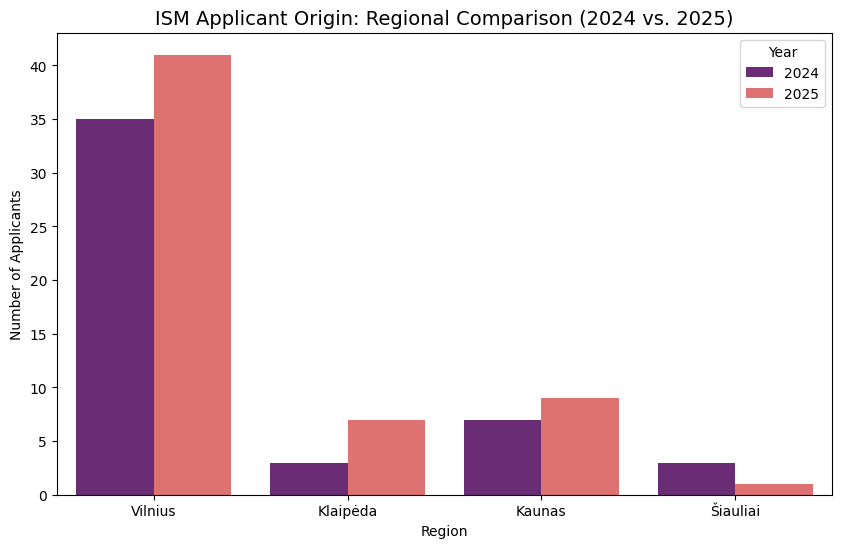

In [18]:
# ISM Regional Performance

regional_growth = pd.DataFrame({
    'Region': ['Vilnius', 'Klaipėda', 'Kaunas', 'Šiauliai'],
    '2024': [35, 3, 7, 3],
    '2025': [41, 7, 9, 1] # data from "ism_regions"
}).melt(id_vars='Region', var_name='Year', value_name='Applicants')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=regional_growth,
    x='Region',
    y='Applicants',
    hue='Year',
    palette='magma'
)

plt.title('ISM Applicant Origin: Regional Comparison (2024 vs. 2025)', fontsize=14)
plt.ylabel('Number of Applicants');

The "Klaipėda Model" is working.

* **Insight:** Interest in Klaipėda more than doubled (from 3 to 7 applicants). Meanwhile, Šiauliai saw a decrease.
* **Action:** The marketing team should analyze the specific events or digital campaigns run in Klaipėda in 2024 and replicate them exactly in Šiauliai and Panevėžys for the 2026 cycle to fix the stagnation in those regions.

**3.4.** Conversion Funnel Efficiency

Finally, I check if ISM’s brand is maintaining its "yield" (the percentage of students who actually sign) as the school grows.

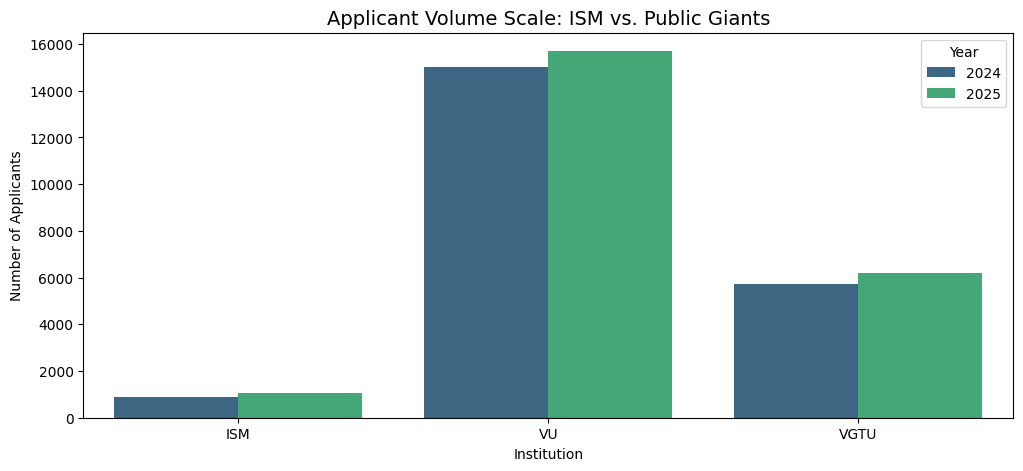

In [19]:
# ISM vs Top Competitors
# Visualizing volume to assess the scale of competition

comp_data = pd.DataFrame({
    'Year': ['2024', '2025', '2024', '2025', '2024', '2025'],
    'Institution': ['ISM', 'ISM', 'VU', 'VU', 'VGTU', 'VGTU'],
    'Applicants': [878, 1044, 14997, 15696, 5714, 6209] # data from "top_competitors"
})

plt.figure(figsize=(12, 5))
sns.barplot(
    data=comp_data,
    x='Institution',
    y='Applicants',
    hue='Year',
    palette='viridis'
)

plt.title('Applicant Volume Scale: ISM vs. Public Giants', fontsize=14)
plt.ylabel('Number of Applicants');

When compared to giants like VU (Vilnius University), ISM remains a "boutique" choice.

* **Insight:** Despite being significantly smaller in absolute volume, ISM’s consistent growth shows it is successfully carving out a high-value niche.
* **Action:** As ISM scales toward 1,100+ applicants, the marketing team must ensure the "conversion funnel" doesn't leak. They should maintain the high-touch, personalized communication that justifies ISM's premium status, ensuring that as volume grows, the "Sign Rate" identified in Task 1 does not drop.